# AutoEncoder for MNIST

In [1]:
import random, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import torch
from sklearn.manifold import TSNE
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

## 參數設定

In [2]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 256  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料

In [3]:
train_ds = datasets.MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())
test_ds = datasets.MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

## 顯示 MNIST 圖像

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_695/3719147394.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax.imshow(np.array(img).squeeze(), cmap='gist_gray')


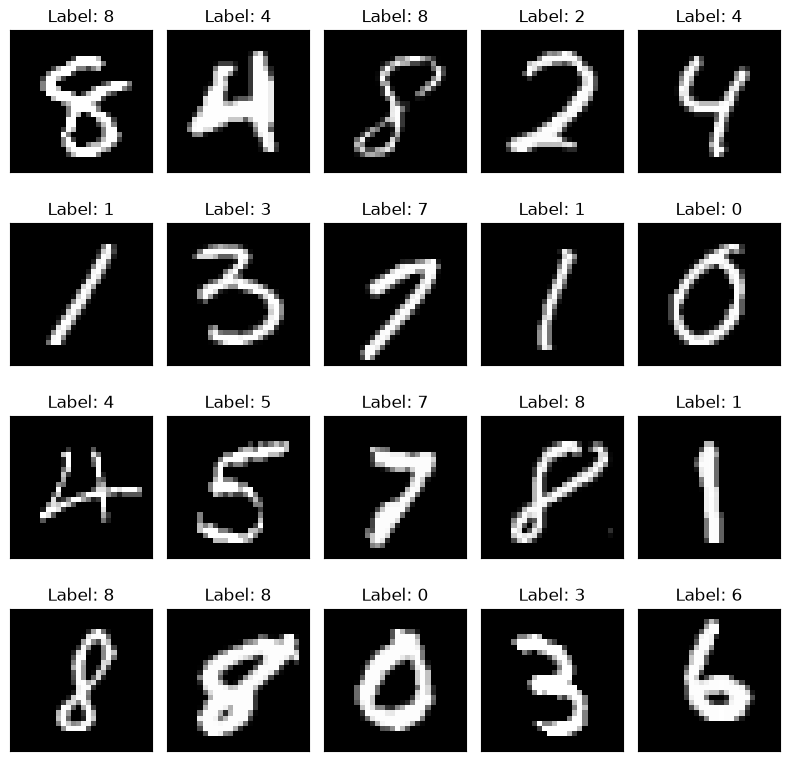

In [4]:
fig, axs = plt.subplots(4, 5, figsize=(8, 8))
for ax in axs.flatten():
    # 隨機抽樣
    img, label = random.choice(train_ds)
    ax.imshow(np.array(img).squeeze(), cmap='gist_gray')
    ax.set_title('Label: %d' % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 建立 DataLoader

In [5]:
# 轉為張量
train_ds.transform = transforms.ToTensor()
test_ds.transform = transforms.ToTensor()

# 切割20%訓練資料作為驗證資料
m = len(train_ds)  # 總筆數
train_data, val_data = random_split(train_ds, [int(m - m * 0.2), int(m * 0.2)])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
valid_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

## 定義模型，含 Encoder and Decoder 

In [6]:
class Encoder(nn.Module):
    def __init__(self, encoded_space_dim: int, fc2_input_dim: int) -> None:
        super().__init__()
        # Convolution
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True),
        )
        self.flatten = nn.Flatten(start_dim=1)
        self.encoder_lin = nn.Sequential(
            nn.Linear(3 * 3 * 32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        return x

In [7]:
class Decoder(nn.Module):
    def __init__(self, encoded_space_dim: int, fc2_input_dim: int) -> None:
        super().__init__()

        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True),
        )
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))
        self.decoder_conv = nn.Sequential(
            # 反卷積
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x: torch.Tensor):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

## 建立模型

In [8]:
# 固定隨機亂數種子，以利掌握執行結果
torch.manual_seed(0)

# encoder 輸出個數、decoder 輸入個數
d = 4
encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128).to(device)

## 定義損失函數及優化器

In [9]:
loss_fn = nn.MSELoss()
lr = 0.001  # Learning rate

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()},
]

optimizer = optim.Adam(params_to_optimize, lr=lr)

## 定義加雜訊(Noise)的函數

In [10]:
def add_noise(inputs: torch.Tensor, noise_factor: float = 0.3) -> torch.Tensor:
    noise = inputs + torch.randn_like(inputs) * noise_factor
    noise = torch.clip(noise, 0.0, 1.0)
    return noise

## 定義訓練函數

In [11]:
def train_epoch_den(
    encoder: nn.Module,
    decoder: nn.Module,
    device: str,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: optim.Optimizer,
    noise_factor: float = 0.3,
) -> float:
    # 指定為訓練階段
    encoder.train()
    decoder.train()
    train_loss = []
    # 訓練
    for image_batch, _ in dataloader:
        # 加雜訊
        image_noisy = add_noise(image_batch, noise_factor)
        image_noisy = image_noisy.to(device)
        # 編碼
        encoded_data = encoder(image_noisy)
        # 解碼
        decoded_data = decoder(encoded_data)
        # 計算損失
        loss: torch.Tensor = loss_fn(decoded_data, image_noisy)
        # 反向傳導
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # print(f'損失：{loss.data}')
        train_loss.append(loss.detach().cpu().numpy())

    return float(np.mean(train_loss))

## 定義測試函數

In [12]:
def test_epoch_den(
    encoder: nn.Module,
    decoder: nn.Module,
    device: str,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    noise_factor: float = 0.3,
) -> torch.Tensor:
    # 指定為評估階段
    encoder.eval()
    decoder.eval()
    with torch.no_grad():  # No need to track the gradients
        conc_out = []
        conc_label = []
        image_batch: torch.Tensor
        for image_batch, _ in dataloader:
            # 加雜訊
            image_noisy = add_noise(image_batch, noise_factor)
            image_noisy = image_noisy.to(device)
            # 編碼
            encoded_data: torch.Tensor = encoder(image_noisy)
            # 解碼
            decoded_data: torch.Tensor = decoder(encoded_data)
            # 輸出存入 conc_out 變數
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # 合併
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label)
        # 驗證資料的損失
        val_loss: torch.Tensor = loss_fn(conc_out, conc_label)
    return val_loss.data

## 定義重建圖像的函數

In [13]:
# fix 中文亂碼
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']
plt.rcParams['axes.unicode_minus'] = False


def plot_ae_outputs_den(
    epoch: int, encoder: nn.Module, decoder: nn.Module, n: int = 5, noise_factor: float = 0.3
) -> None:
    plt.figure(figsize=(10, 4.5))
    for i in range(n):
        ax = plt.subplot(3 if epoch == 0 else 1, n, i + 1)
        img: torch.Tensor = test_ds[i][0].unsqueeze(0)
        image_noisy = add_noise(img, noise_factor)
        image_noisy = image_noisy.to(device)

        encoder.eval()
        decoder.eval()

        with torch.no_grad():
            rec_img: torch.Tensor = decoder(encoder(image_noisy))

        if epoch == 0:
            plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n // 2:
                ax.set_title('原圖')
            ax = plt.subplot(3, n, i + 1 + n)
            plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n // 2:
                ax.set_title('加雜訊')

        if epoch == 0:
            ax = plt.subplot(3, n, i + 1 + n + n)
        else:
            ax = plt.subplot(1, n, i + 1)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if epoch == 0 and i == n // 2:
            ax.set_title('重建圖像')
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.7, top=0.9, wspace=0.3, hspace=0.3)
    plt.show()

## 訓練

EPOCH 1/30 	 訓練損失：0.100 	 驗證損失： 0.072


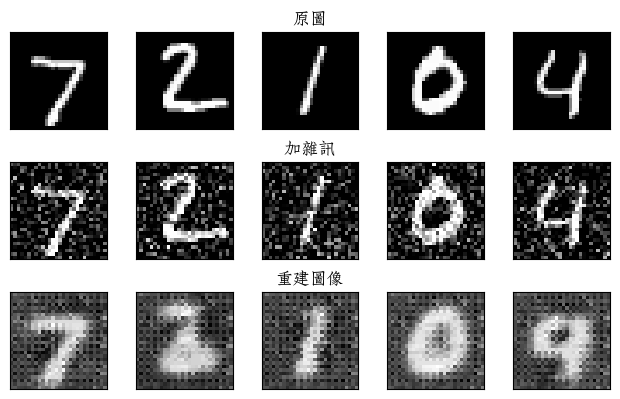

EPOCH 2/30 	 訓練損失：0.062 	 驗證損失： 0.055


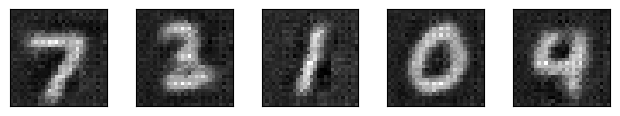

EPOCH 3/30 	 訓練損失：0.057 	 驗證損失： 0.047


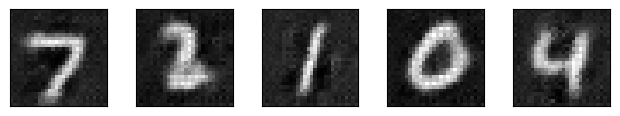

EPOCH 4/30 	 訓練損失：0.054 	 驗證損失： 0.044


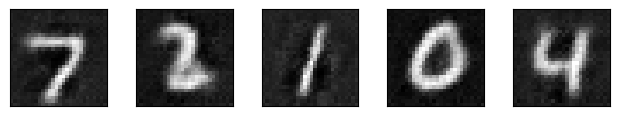

EPOCH 5/30 	 訓練損失：0.053 	 驗證損失： 0.042


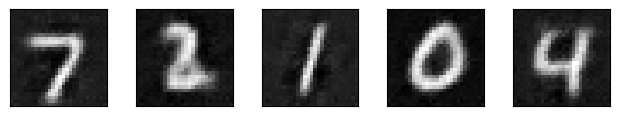

EPOCH 6/30 	 訓練損失：0.052 	 驗證損失： 0.041


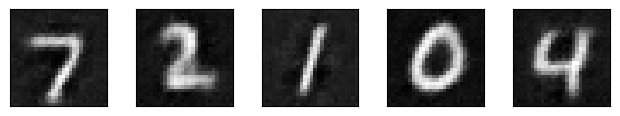

EPOCH 7/30 	 訓練損失：0.052 	 驗證損失： 0.041


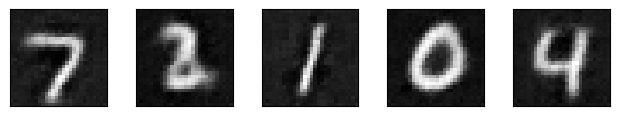

EPOCH 8/30 	 訓練損失：0.052 	 驗證損失： 0.041


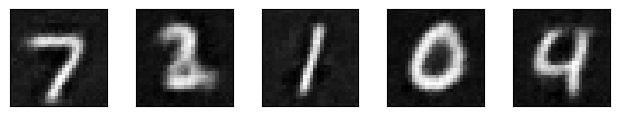

EPOCH 9/30 	 訓練損失：0.051 	 驗證損失： 0.040


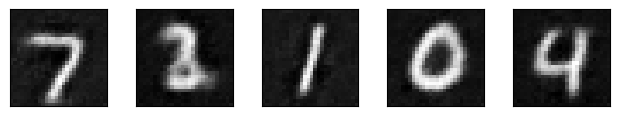

EPOCH 10/30 	 訓練損失：0.051 	 驗證損失： 0.040


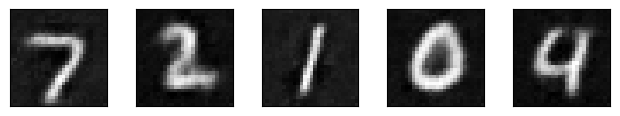

EPOCH 11/30 	 訓練損失：0.051 	 驗證損失： 0.040


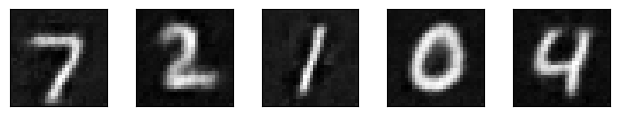

EPOCH 12/30 	 訓練損失：0.051 	 驗證損失： 0.040


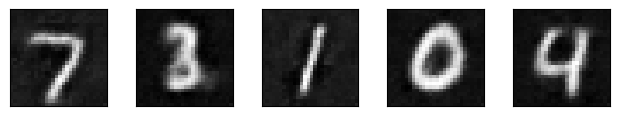

EPOCH 13/30 	 訓練損失：0.051 	 驗證損失： 0.039


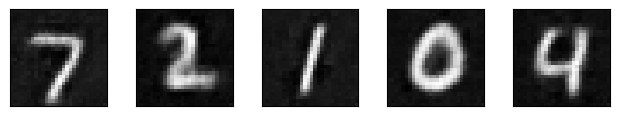

EPOCH 14/30 	 訓練損失：0.051 	 驗證損失： 0.039


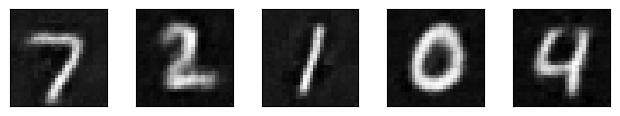

EPOCH 15/30 	 訓練損失：0.051 	 驗證損失： 0.039


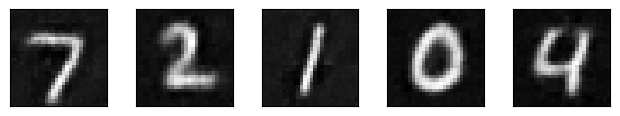

EPOCH 16/30 	 訓練損失：0.050 	 驗證損失： 0.039


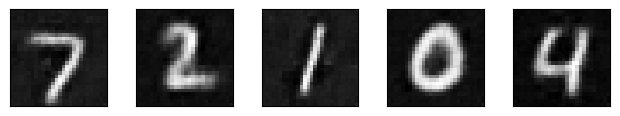

EPOCH 17/30 	 訓練損失：0.050 	 驗證損失： 0.039


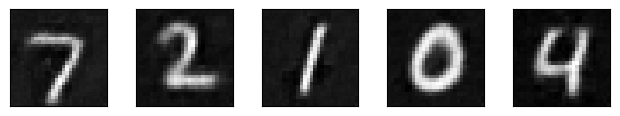

EPOCH 18/30 	 訓練損失：0.050 	 驗證損失： 0.039


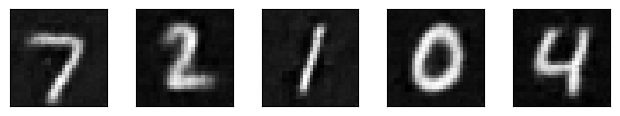

EPOCH 19/30 	 訓練損失：0.050 	 驗證損失： 0.039


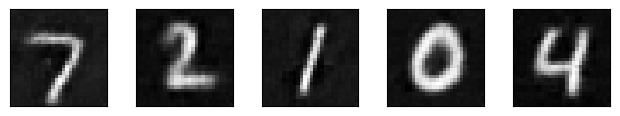

EPOCH 20/30 	 訓練損失：0.050 	 驗證損失： 0.038


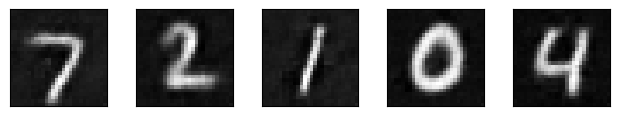

EPOCH 21/30 	 訓練損失：0.050 	 驗證損失： 0.038


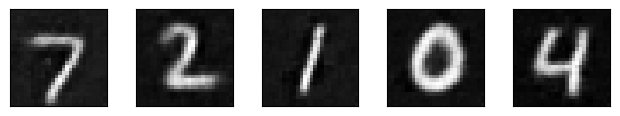

EPOCH 22/30 	 訓練損失：0.050 	 驗證損失： 0.038


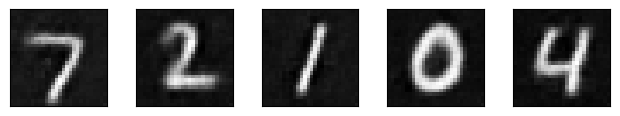

EPOCH 23/30 	 訓練損失：0.050 	 驗證損失： 0.038


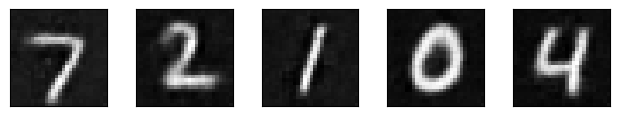

EPOCH 24/30 	 訓練損失：0.050 	 驗證損失： 0.038


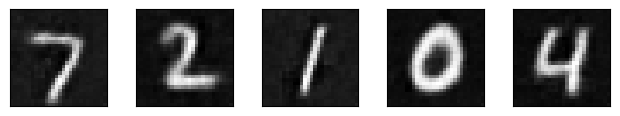

EPOCH 25/30 	 訓練損失：0.050 	 驗證損失： 0.038


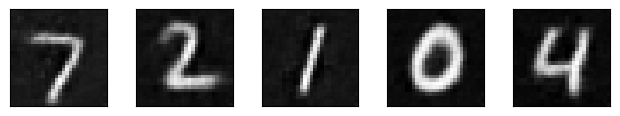

EPOCH 26/30 	 訓練損失：0.050 	 驗證損失： 0.038


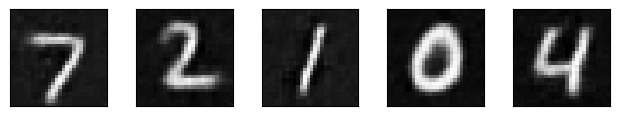

EPOCH 27/30 	 訓練損失：0.050 	 驗證損失： 0.038


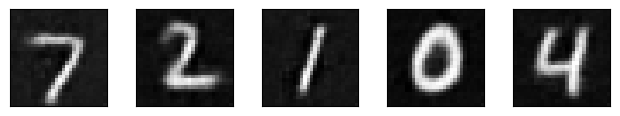

EPOCH 28/30 	 訓練損失：0.050 	 驗證損失： 0.038


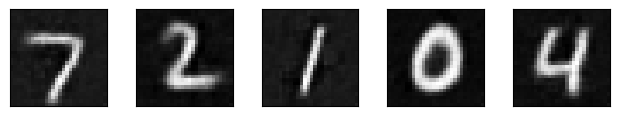

EPOCH 29/30 	 訓練損失：0.050 	 驗證損失： 0.038


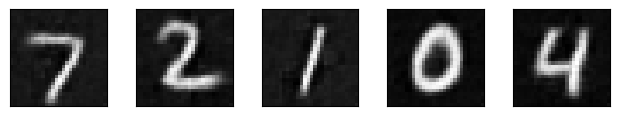

EPOCH 30/30 	 訓練損失：0.050 	 驗證損失： 0.038


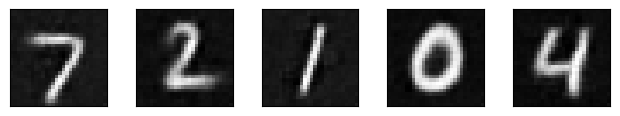

In [14]:
noise_factor = 0.3
num_epochs = 30
history_da = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    # print(f'EPOCH {epoch + 1}/{num_epochs}')
    # 訓練
    train_loss = train_epoch_den(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        noise_factor=noise_factor,
    )
    # 驗證
    val_loss = test_epoch_den(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=valid_loader,
        loss_fn=loss_fn,
        noise_factor=noise_factor,
    )
    # Print Validation loss
    history_da['train_loss'].append(train_loss)
    history_da['val_loss'].append(val_loss)
    print(f'EPOCH {epoch + 1}/{num_epochs} \t 訓練損失：{train_loss:.3f}' + f' \t 驗證損失： {val_loss:.3f}')
    plot_ae_outputs_den(epoch, encoder, decoder, noise_factor=noise_factor)

In [15]:
test_epoch_den(encoder, decoder, device, test_loader, loss_fn).item()

0.038029447197914124

## 使用隨機亂數生成圖像

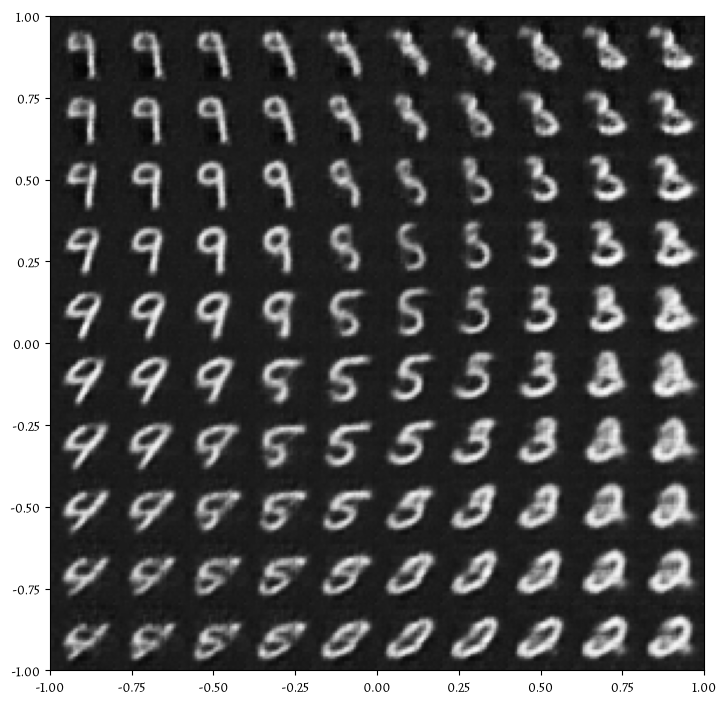

In [16]:
def plot_reconstructed(
    decoder: nn.Module, r0: tuple[float, float] = (-5, 10), r1: tuple[float, float] = (-10, 5), n: int = 10
) -> None:
    plt.figure(figsize=(20, 8.5))
    w = 28
    img = np.zeros((n * w, n * w))
    # 隨機亂數
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y], [x, y]]).reshape(-1, 4).to(device)
            # print(z.shape)
            x_hat = decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n - 1 - i) * w : (n - 1 - i + 1) * w, j * w : (j + 1) * w] = x_hat
    plt.imshow(img, extent=(*r0, *r1), cmap='gist_gray')


plot_reconstructed(decoder, r0=(-1, 1), r1=(-1, 1))

## 觀察模型中間的潛在因子(Latent Factor)，即編碼器的輸出

In [17]:
encoded_sample_list = []
for sample in test_ds:
    img = sample[0].unsqueeze(0).to(device)
    label = sample[1]
    # Encode image
    encoder.eval()
    with torch.no_grad():
        encoded_img = encoder(img)
    # Append to list
    encoded_img = encoded_img.flatten().cpu().numpy()
    encoded_sample = {f"變數 {i}": enc for i, enc in enumerate(encoded_img)}
    encoded_sample['label'] = label
    encoded_sample_list.append(encoded_sample)

encoded_samples = pd.DataFrame(encoded_sample_list)
encoded_samples

,變數 0,變數 1,變數 2,變數 3,label
0,-3.631435,1.398197,0.051735,0.301323,7
1,-0.261783,1.306458,1.949417,-0.652263,2
2,-0.662963,1.859264,-0.112869,-1.015289,1
3,0.661913,-0.813188,-0.057033,0.196984,0
4,-0.178021,-0.068162,-1.401950,0.456817,4
...,...,...,...,...,...
9995,-0.611917,0.374094,2.432628,-0.497204,2
9996,0.403324,0.076975,0.957729,0.381239,3
9997,-0.854696,0.580103,-1.577478,-0.318500,4
9998,-0.292628,-0.558931,-0.453059,-0.914571,5


In [18]:
fig = px.scatter(encoded_samples, x='變數 0', y='變數 1', color=encoded_samples.label.astype(str), opacity=0.7)
fig

## TSNE 降維

In [19]:
# TSNE 降維
tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(encoded_samples.drop(['label'], axis=1))

# 繪圖
fig = px.scatter(
    tsne_results, x=0, y=1, color=encoded_samples.label.astype(str), labels={'0': 'tsne-變數1', '1': 'tsne-變數2'}
)
fig